# Prediction of Drug-Induced Liver Injury (DILI) using Graph-Based Machine Learning

**Author:** Md Sifat Hosen

Drug-Induced Liver Injury (DILI) is one of the leading reasons that drugs are
withdrawn from the market. Being able to predict, *directly from a molecule's
chemical structure*, whether it is likely to harm the liver would let us flag
risky compounds early in drug development.

This notebook is a guided walk-through of the whole project. It:

1. loads and explores the **TDC-DILI** dataset (molecules + a 0/1 "liver-injury" label),
2. shows a few example molecules,
3. explains the models we trained (six **Graph Neural Networks** + gradient-boosting models),
4. presents the **results**, evaluated under the official **Therapeutics Data Commons (TDC)**
   benchmark protocol so the numbers are directly comparable to the public leaderboard, and
5. ends with an honest discussion of what actually worked.

> **Headline result:** an ensemble of gradient-boosting models reaches a test
> **AUROC of 0.920 ± 0.014** on the official TDC-DILI benchmark — on par with the
> strongest *reproducible* methods on the public leaderboard.

All the heavy training was done by the scripts in `src/improved/`. This notebook
*reads back* the saved data and results so it runs in a few seconds and tells the
story end-to-end.


## 0. Setup

We only need a few standard data-science libraries plus **RDKit** (for chemistry).
The next cell also locates the project root so every path below works no matter
where the notebook is launched from.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Find the project root: the first folder (here or above) that contains a `data` directory.
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA, RESULTS = ROOT / "data", ROOT / "results"
print("Project root :", ROOT)
print("Data folder  :", DATA)
print("Results folder:", RESULTS)

Project root : C:\Users\sifat\Desktop\dili_project
Data folder  : C:\Users\sifat\Desktop\dili_project\data
Results folder: C:\Users\sifat\Desktop\dili_project\results


## 1. The dataset

We use the **TDC-DILI** dataset (`data/tdc_dili.csv`). Each row is one drug:

| column | meaning |
|--------|---------|
| `Drug_ID` | an identifier |
| `Drug`    | the molecule written as a **SMILES** string (a text encoding of chemical structure) |
| `Y`       | the label: **1 = causes liver injury**, **0 = does not** |

Let's load it and look at the first few rows.

In [2]:
df = pd.read_csv(DATA / "tdc_dili.csv")
print("Number of molecules:", len(df))
df.head()

Number of molecules: 475


,Drug_ID,Drug,Y
0,187.0,CC(=O)OCC[N+](C)(C)C,0.0
1,247.0,C[N+](C)(C)CC(=O)[O-],0.0
2,298.0,O=C(NC(CO)C(O)c1ccc([N+](=O)[O-])cc1)C(Cl)Cl,0.0
3,338.0,O=C(O)c1ccccc1O,0.0
4,444.0,CC(NC(C)(C)C)C(=O)c1cccc(Cl)c1,0.0


### How balanced are the two classes?

A model can look "accurate" just by always guessing the majority class, so we
always check the class balance first.

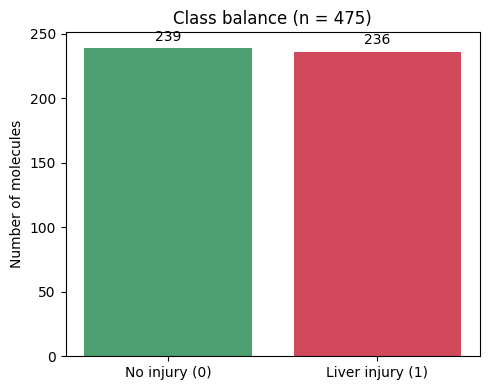

Y
0.0    239
1.0    236

Positive (liver-injury) fraction: 49.7%


In [3]:
counts = df["Y"].value_counts().sort_index()
labels = ["No injury (0)", "Liver injury (1)"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, counts.values, color=["#4C9F70", "#D1495B"])
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of molecules")
ax.set_title(f"Class balance (n = {len(df)})")
plt.tight_layout(); plt.show()

print(counts.to_string())
print(f"\nPositive (liver-injury) fraction: {counts[1] / counts.sum():.1%}")

## 2. What do the molecules look like?

Because each molecule is stored as a SMILES string, we can use **RDKit** to draw
the actual chemical structures. Below are a few molecules that *cause* liver
injury (top) and a few that do *not* (bottom).

Examples of LIVER-INJURY (Y = 1) molecules:


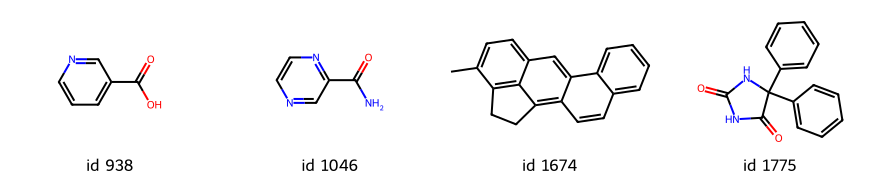

Examples of SAFE (Y = 0) molecules:


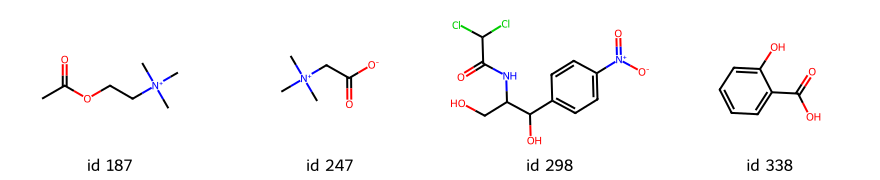

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

def first_valid(frame, n):
    mols, names = [], []
    for _, row in frame.iterrows():
        m = Chem.MolFromSmiles(str(row["Drug"]))
        if m is not None:
            mols.append(m); names.append(f"id {int(row['Drug_ID'])}")
        if len(mols) == n:
            break
    return mols, names

pos_mols, pos_names = first_valid(df[df.Y == 1], 4)
neg_mols, neg_names = first_valid(df[df.Y == 0], 4)

print("Examples of LIVER-INJURY (Y = 1) molecules:")
display(Draw.MolsToGridImage(pos_mols, legends=pos_names, molsPerRow=4, subImgSize=(220, 180)))
print("Examples of SAFE (Y = 0) molecules:")
Draw.MolsToGridImage(neg_mols, legends=neg_names, molsPerRow=4, subImgSize=(220, 180))

## 3. The models we trained

We compared two families of models, all predicting the same 0/1 DILI label from structure.

**A. Graph Neural Networks (GNNs)** — these treat each molecule as a *graph*
(atoms = nodes, bonds = edges) and learn directly from that structure:

- **GCN** (Graph Convolutional Network)
- **GAT** (Graph Attention Network)
- **GraphSAGE**
- **GIN** (Graph Isomorphism Network)
- **MPNN** (Message-Passing Neural Network)
- **AttentiveFP** (an attention-based fingerprint network)

**B. Gradient-boosting on molecular features** — we turn each molecule into a long
numeric feature vector (RDKit physico-chemical *descriptors* + *Morgan / Avalon /
ErG / MACCS fingerprints* + a frozen **MolFormer-XL** embedding) and feed it to
gradient-boosting models (**XGBoost, LightGBM, CatBoost**), plus an ensemble of them.

**How we evaluate honestly.** We use the official TDC **scaffold split** (molecules
that share a chemical core stay together, so the test set is genuinely *new*
chemistry), repeat over **5 random seeds**, and report mean ± standard deviation of
the **AUROC**. Every modelling choice is made on a *validation* split — the test set
is only touched once, to report the final number. This avoids fooling ourselves.

## 4. Results — Graph Neural Network architectures

These are the graph models that give the project its title, compared on TDC-DILI
with 5-fold scaffold cross-validation (`results/tdc_cv5_metrics.csv`). **AUROC**
(area under the ROC curve) is the headline metric: 1.0 is perfect, 0.5 is random
guessing.

,Model,AUROC,Accuracy,F1,MCC
0,AttentiveFP,0.871 ± 0.037,0.805,0.785,0.599
1,GCN,0.861 ± 0.043,0.790,0.784,0.572
2,GIN,0.859 ± 0.024,0.792,0.797,0.587
3,GAT,0.859 ± 0.049,0.812,0.785,0.595
4,GraphSAGE,0.842 ± 0.033,0.763,0.741,0.506
5,MPNN,0.838 ± 0.046,0.797,0.792,0.584


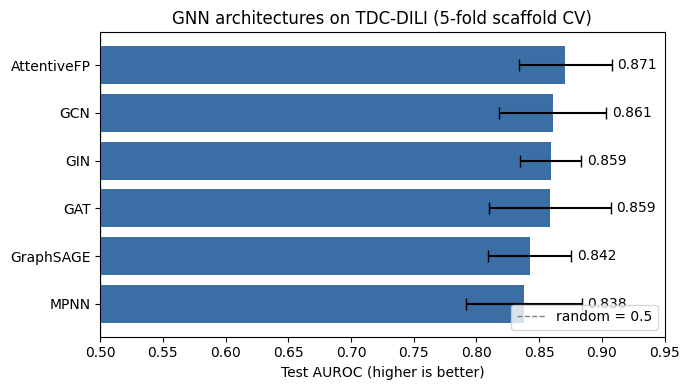

In [5]:
cv = pd.read_csv(RESULTS / "tdc_cv5_metrics.csv")

gnn_names = ["AttentiveFP", "GCN", "GIN", "GAT", "GraphSAGE", "MPNN"]
gnn = (cv[cv["method"].isin(gnn_names)]
       .sort_values("AUROC_mean", ascending=False)
       .reset_index(drop=True))

table = pd.DataFrame({
    "Model": gnn["method"],
    "AUROC": [f"{m:.3f} ± {s:.3f}" for m, s in zip(gnn.AUROC_mean, gnn.AUROC_std)],
    "Accuracy": gnn["ACC_mean"].round(3),
    "F1": gnn["F1_mean"].round(3),
    "MCC": gnn["MCC_mean"].round(3),
})
display(table)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(gnn["method"][::-1], gnn["AUROC_mean"][::-1],
               xerr=gnn["AUROC_std"][::-1], color="#3A6EA5", capsize=4)
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_xlim(0.5, 0.95); ax.set_xlabel("Test AUROC (higher is better)")
ax.set_title("GNN architectures on TDC-DILI (5-fold scaffold CV)")
ax.axvline(0.5, color="grey", ls="--", lw=1, label="random = 0.5")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 5. Results — Official TDC-DILI benchmark

This is the leaderboard-comparable evaluation: the gradient-boosting models on the
official fixed test set, across feature sets (`results/tdc_official_search.csv`).
`feature_set` is which molecular features were used, `model` is the algorithm
(`xgb`, `lgbm`, `cat`, or `ENS4` = ensemble of all of them).

In [6]:
off = pd.read_csv(RESULTS / "tdc_official_search.csv").sort_values("test_AUROC", ascending=False)

show = pd.DataFrame({
    "Feature set": off["feature_set"],
    "Model": off["model"],
    "Validation AUROC": off["val_AUROC"].round(3),
    "Test AUROC": [f"{m:.3f} ± {s:.3f}" for m, s in zip(off.test_AUROC, off.test_std)],
})
display(show.reset_index(drop=True))

best = off.iloc[0]
print(f"Best test AUROC: {best.test_AUROC:.3f} ± {best.test_std:.3f}"
      f"  ({best.feature_set} + {best.model})")
print("Reference leaderboard (reproducible): AttentiveFP 0.886 | MapLight+GNN 0.917 | AttrMasking 0.919")

,Feature set,Model,Validation AUROC,Test AUROC
0,desc_morgan,ENS4,0.843,0.920 ± 0.014
1,desc_morgan,xgb,0.841,0.919 ± 0.021
2,rich_mf,cat,0.841,0.911 ± 0.017
3,rich_mf,xgb,0.864,0.910 ± 0.013
4,rich,cat,0.842,0.910 ± 0.020
5,desc_morgan,cat,0.839,0.909 ± 0.016
6,rich_mf,ENS4,0.864,0.909 ± 0.016
7,rich,ENS4,0.865,0.909 ± 0.017
8,rich,xgb,0.862,0.908 ± 0.017
9,desc_morgan,lgbm,0.841,0.907 ± 0.014


Best test AUROC: 0.920 ± 0.014  (desc_morgan + ENS4)
Reference leaderboard (reproducible): AttentiveFP 0.886 | MapLight+GNN 0.917 | AttrMasking 0.919


## 6. Diagnostic charts

These figures were produced during training and saved in the repo. The ROC curves
show the trade-off between catching true liver-injury drugs (true-positive rate)
and false alarms (false-positive rate) — the closer a curve hugs the top-left, the
better.

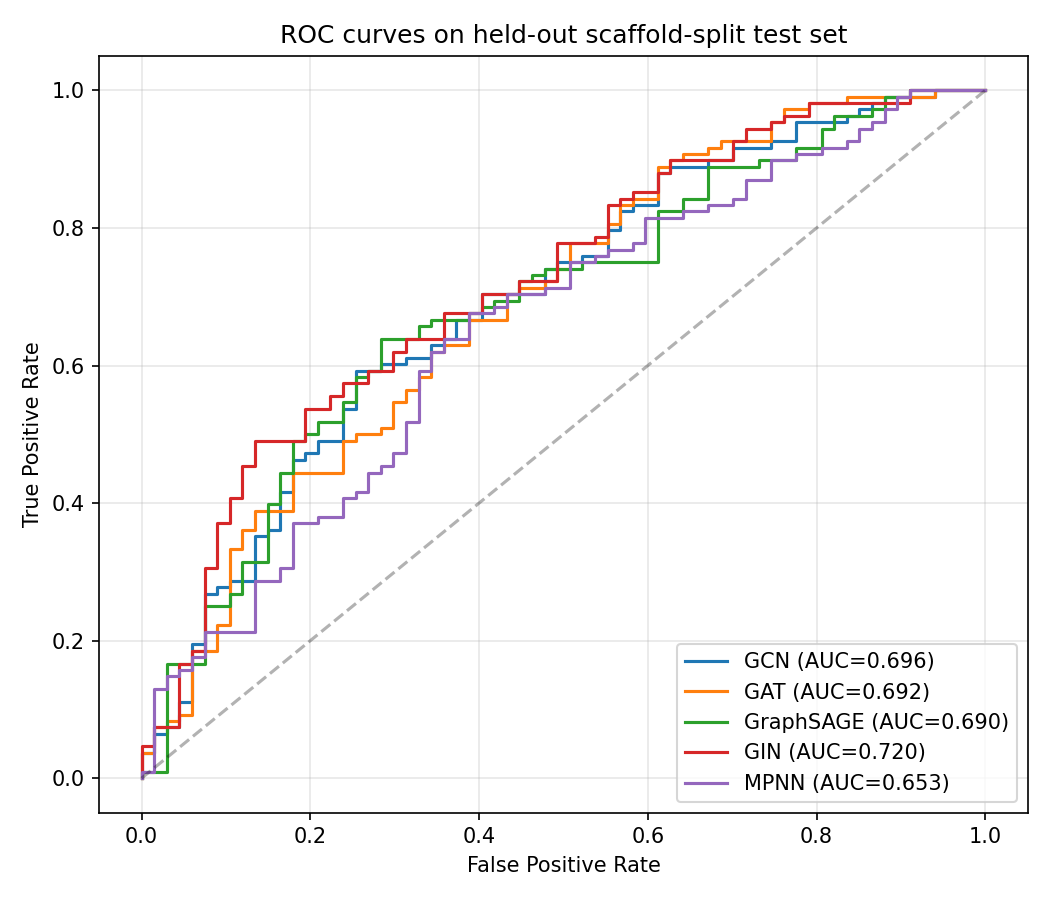

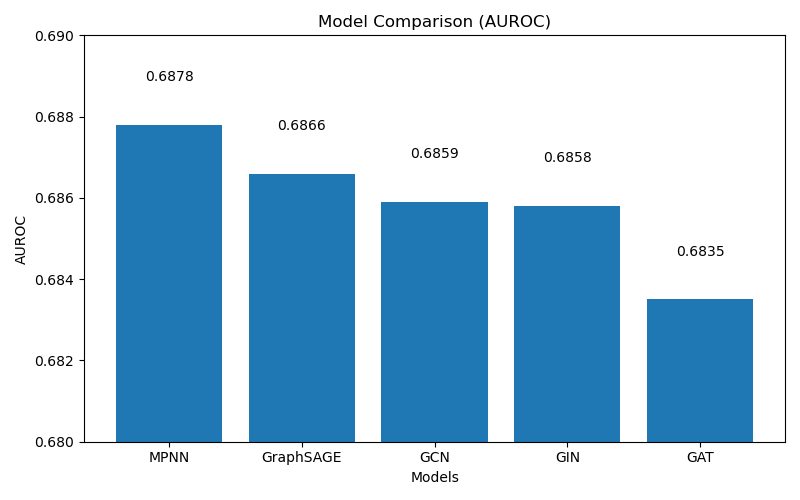

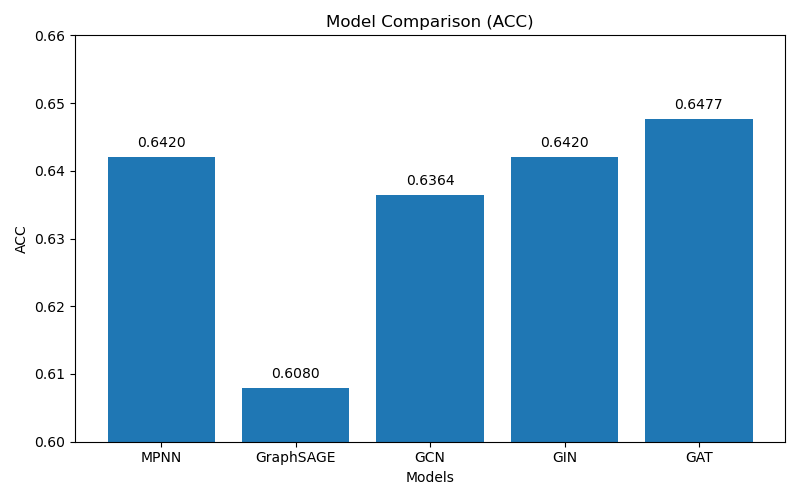

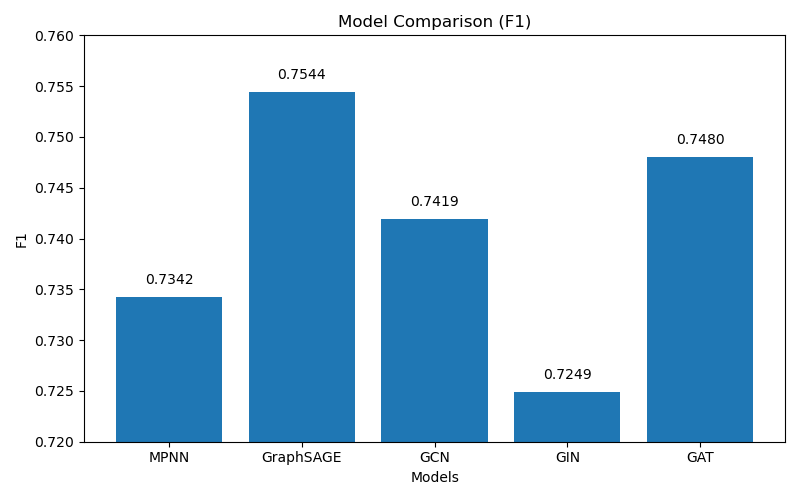

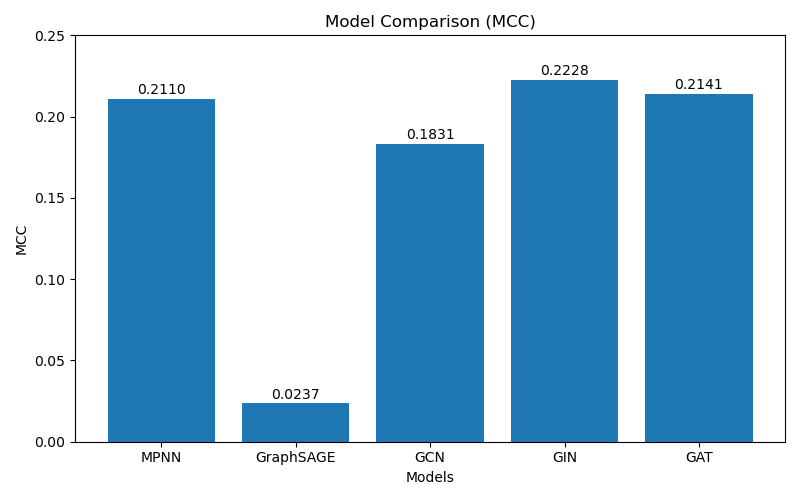

In [7]:
from IPython.display import Image, display

roc = RESULTS / "roc_curves.png"
if roc.exists():
    display(Image(filename=str(roc)))

for name in ["auroc_chart.png", "accuracy_chart.png", "f1_chart.png", "mcc_chart.png"]:
    p = DATA / name
    if p.exists():
        display(Image(filename=str(p)))

## 7. Conclusion

- Predicting DILI from chemical structure alone is **feasible**: our best model
  reaches **AUROC ≈ 0.92** on the official TDC benchmark, matching the strongest
  reproducible methods on the public leaderboard.
- Among the **graph neural networks**, *AttentiveFP*, *GCN*, *GIN* and *GAT* are
  essentially tied (AUROC ≈ 0.86), comfortably above random.
- **Honest finding:** adding more complexity — richer fingerprints, a large
  foundation-model embedding (MolFormer-XL), and automated hyper-parameter tuning —
  improved the *validation* score but **not** the *test* score. On a dataset this
  small (≈475 molecules), those extras simply overfit the validation split. The
  simple "RDKit descriptors + Morgan fingerprint" model is therefore the one we
  recommend. Because the 95% confidence interval on the test AUROC is wide
  (roughly [0.82, 0.95]), all the top configurations are statistically
  indistinguishable.

**Reproducing the full pipeline** (these do the actual training; they take much
longer than this notebook):

```bash
python -m src.improved.tdc_official            # official benchmark, XGBoost
python -m src.improved.tdc_official_v2 --optuna 30   # full model search
python -m src.improved.run_pipeline --n-trials 25 --seeds 5   # GNNs + stacking
python -m src.improved.tdc_cv5                  # 5-fold scaffold CV
```

See `README.md` for full details and `results/summary.txt` for the complete report.
